# Job Acceptance Prediction System
## Notebook 01 — Data Cleaning & Preprocessing


1. Import libraries and verify environment
2. Configure project paths
3. Load raw dataset
4. Inspect structure and data types
5. Analyze missing values
6. Analyze exact and duplicate-like records
7. Standardize categorical values
8. Validate numeric values
9. Validate salary fields
10. Handle missing values
11. Validate the target variable
12. Perform final quality checks
13. Save and verify the cleaned dataset



In [1]:
# 1. Import libraries
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# 2. Verify Python and package versions
import sklearn

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas: 3.0.6
NumPy: 2.4.6
Scikit-learn: 1.9.1


In [3]:
# 3. Configure project paths

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

RAW_PATH = os.path.join(
    PROJECT_ROOT, "data", "raw", "job_acceptance_raw.csv"
)

PROCESSED_DIR = os.path.join(
    PROJECT_ROOT, "data", "processed"
)

CLEAN_PATH = os.path.join(
    PROCESSED_DIR, "cleaned_job_acceptance_data.csv"
)

os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dataset:", RAW_PATH)
print("Cleaned dataset:", CLEAN_PATH)


Project root: d:\job acceptance prediction system
Raw dataset: d:\job acceptance prediction system\data\raw\job_acceptance_raw.csv
Cleaned dataset: d:\job acceptance prediction system\data\processed\cleaned_job_acceptance_data.csv


In [4]:
# 4. Verify and load raw dataset

if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        f"Raw dataset not found at: {RAW_PATH}"
    )

df = pd.read_csv(RAW_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())


Rows: 50,000
Columns: 36


,Candidate_ID,Age,Gender,Education_Level,Degree_Field,University_Tier,CGPA,Years_of_Experience,Previous_Companies,Internship_Experience,Certifications_Count,Technical_Skills_Score,Soft_Skills_Score,Skills_Match_Percentage,Aptitude_Score,Communication_Score,Interview_Score,Interview_Rounds,Job_Role,Industry,Company_Tier,Company_Size,Job_Type,Work_Mode,Job_Location,Preferred_Location,Relocation_Willingness,Competition_Level,Expected_Salary,Offered_Salary,Career_Growth_Score,Benefits_Score,Job_Security_Score,Notice_Period_Days,Offer_to_Joining_Days,Job_Accepted
0,CAND00001,28.00,Male,Diploma,Computer Science,Tier 2,NaN,5.20,3.00,No,0.00,74.40,78.50,54.50,88.50,80.90,80.30,3,Data Scientist,Telecom,Tier 3,Small,Contract,Hybrid,Mumbai,Pune,Yes,Medium,"1,225,000.00","1,198,000.00",92.10,62.00,77.50,30,54,0
1,CAND00002,22.00,Female,Bachelor's,Engineering,Tier 3,7.74,1.50,0.00,No,5.00,58.60,95.70,37.50,81.50,81.60,92.30,5,Data Scientist,Healthcare,Tier 2,Large,Part-Time,Hybrid,Mumbai,Bangalore,No,Medium,"1,029,000.00","1,168,000.00",93.80,94.60,55.40,30,44,1
2,CAND00003,30.00,Female,Master's,Business Administration,Tier 1,8.28,5.10,3.00,Yes,1.00,99.40,NaN,72.80,82.80,57.80,82.90,4,Operations Analyst,Consulting,Tier 1,Medium,Full-Time,Hybrid,Delhi,Delhi,Yes,Medium,"644,000.00","681,000.00",84.40,65.90,66.30,30,31,0
3,CAND00004,31.00,Female,Bachelor's,Data Science,Tier 2,7.96,5.50,3.00,No,3.00,NaN,87.20,57.30,75.10,72.40,83.50,3,Software Engineer,Consulting,Tier 1,Small,Full-Time,Hybrid,Bangalore,Hyderabad,No,Low,"1,166,000.00","1,213,000.00",87.30,85.60,79.70,45,58,1
4,CAND00005,20.00,Male,Bachelor's,Computer Science,Tier 3,7.96,0.00,0.00,No,2.00,63.90,80.40,44.00,NaN,75.60,69.30,3,Marketing Analyst,IT,Tier 1,Large,Full-Time,Remote,Hyderabad,Hyderabad,Yes,Medium,"597,000.00","666,000.00",83.70,76.40,79.30,15,37,1


## 1. Initial Dataset Inspection


In [5]:
# 5. Display column names

for number, column in enumerate(df.columns, start=1):
    print(f"{number:02d}. {column}")


01. Candidate_ID
02. Age
03. Gender
04. Education_Level
05. Degree_Field
06. University_Tier
07. CGPA
08. Years_of_Experience
09. Previous_Companies
10. Internship_Experience
11. Certifications_Count
12. Technical_Skills_Score
13. Soft_Skills_Score
14. Skills_Match_Percentage
15. Aptitude_Score
16. Communication_Score
17. Interview_Score
18. Interview_Rounds
19. Job_Role
20. Industry
21. Company_Tier
22. Company_Size
23. Job_Type
24. Work_Mode
25. Job_Location
26. Preferred_Location
27. Relocation_Willingness
28. Competition_Level
29. Expected_Salary
30. Offered_Salary
31. Career_Growth_Score
32. Benefits_Score
33. Job_Security_Score
34. Notice_Period_Days
35. Offer_to_Joining_Days
36. Job_Accepted


In [6]:
# 6. Structure and data types

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Missing_Count": df.isna().sum().values,
    "Unique_Values": df.nunique(dropna=True).values
})

display(dtype_summary)
df.info()


,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Values
0,Candidate_ID,str,50000,0,50000
1,Age,float64,50000,0,123
2,Gender,str,48751,1249,6
3,Education_Level,str,50000,0,8
4,Degree_Field,str,50000,0,9
5,University_Tier,str,50000,0,3
6,CGPA,float64,47754,2246,574
7,Years_of_Experience,float64,48247,1753,151
8,Previous_Companies,float64,48751,1249,10
9,Internship_Experience,str,50000,0,2


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Candidate_ID             50000 non-null  str    
 1   Age                      50000 non-null  float64
 2   Gender                   48751 non-null  str    
 3   Education_Level          50000 non-null  str    
 4   Degree_Field             50000 non-null  str    
 5   University_Tier          50000 non-null  str    
 6   CGPA                     47754 non-null  float64
 7   Years_of_Experience      48247 non-null  float64
 8   Previous_Companies       48751 non-null  float64
 9   Internship_Experience    50000 non-null  str    
 10  Certifications_Count     48503 non-null  float64
 11  Technical_Skills_Score   48003 non-null  float64
 12  Soft_Skills_Score        48003 non-null  float64
 13  Skills_Match_Percentage  47501 non-null  float64
 14  Aptitude_Score           48252 no

In [7]:
# 7. Numerical descriptive statistics
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Age,"50,000.00",27.14,4.35,17.08,24.00,27.00,30.00,57.95
CGPA,"47,754.00",7.60,1.04,3.26,6.89,7.60,8.31,11.29
Years_of_Experience,"48,247.00",3.60,2.90,0.00,1.20,3.30,5.40,15.00
Previous_Companies,"48,751.00",1.87,1.58,0.00,1.00,2.00,3.00,9.00
Certifications_Count,"48,503.00",2.01,1.41,0.00,1.00,2.00,3.00,8.00
Technical_Skills_Score,"48,003.00",76.32,10.93,-4.82,69.10,76.40,83.70,106.91
Soft_Skills_Score,"48,003.00",71.97,11.97,12.23,63.90,72.00,80.10,104.97
Skills_Match_Percentage,"47,501.00",53.54,10.12,-6.90,46.70,53.60,60.40,114.23
Aptitude_Score,"48,252.00",77.60,12.80,-8.77,69.10,77.90,86.80,109.76
Communication_Score,"48,003.00",73.33,8.08,8.33,68.00,73.40,78.80,109.98


In [8]:
# 8. Categorical descriptive statistics
display(df.describe(include="object").T)


,count,unique,top,freq
Candidate_ID,50000,50000,CAND00001,1
Gender,48751,6,Male,27788
Education_Level,50000,8,Bachelor's,25718
Degree_Field,50000,9,Computer Science,10073
University_Tier,50000,3,Tier 2,22300
Internship_Experience,50000,2,Yes,29180
Job_Role,50000,8,Software Engineer,9838
Industry,50000,8,IT,15137
Company_Tier,50000,3,Tier 2,25142
Company_Size,50000,3,Medium,25227


## 2. Missing Value Analysis


In [9]:
# 9. Missing-value summary

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean() * 100
}).sort_values("Missing_Count", ascending=False)

display(missing_summary)


,Missing_Count,Missing_Percentage
Skills_Match_Percentage,2499,5.00
CGPA,2246,4.49
Expected_Salary,2246,4.49
Career_Growth_Score,2005,4.01
Communication_Score,1997,3.99
Technical_Skills_Score,1997,3.99
Soft_Skills_Score,1997,3.99
Years_of_Experience,1753,3.51
Benefits_Score,1752,3.50
Offered_Salary,1749,3.50


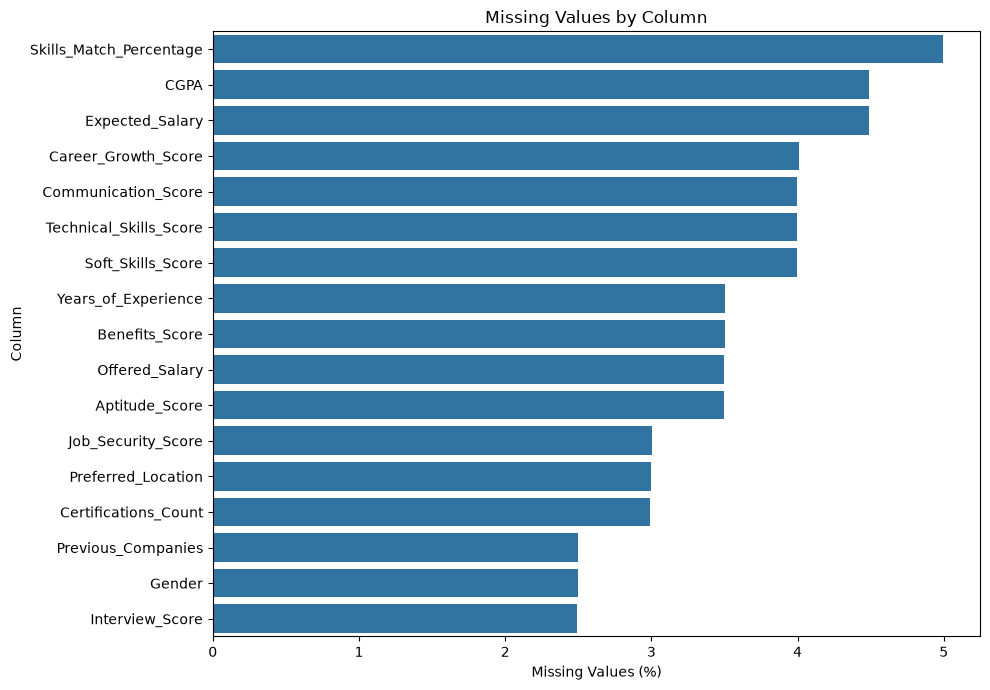

In [10]:
# 10. Visualize missing values

missing_columns = missing_summary[
    missing_summary["Missing_Count"] > 0
]

if not missing_columns.empty:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        x="Missing_Percentage",
        y=missing_columns.index,
        data=missing_columns
    )
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


## 3. Duplicate Analysis


In [11]:
# 11. Exact duplicates

exact_duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicate_count:,}")


Exact duplicate rows: 0


In [12]:
# 12. Duplicate-like records excluding Candidate_ID

duplicate_features = [
    column for column in df.columns
    if column != "Candidate_ID"
]

duplicate_like_mask = df.duplicated(
    subset=duplicate_features,
    keep=False
)

duplicate_like_count = int(duplicate_like_mask.sum())

print(
    "Rows involved in duplicate-like groups "
    f"(excluding Candidate_ID): {duplicate_like_count:,}"
)

if duplicate_like_count > 0:
    display(df.loc[duplicate_like_mask].head(20))


Rows involved in duplicate-like groups (excluding Candidate_ID): 280


,Candidate_ID,Age,Gender,Education_Level,Degree_Field,University_Tier,CGPA,Years_of_Experience,Previous_Companies,Internship_Experience,Certifications_Count,Technical_Skills_Score,Soft_Skills_Score,Skills_Match_Percentage,Aptitude_Score,Communication_Score,Interview_Score,Interview_Rounds,Job_Role,Industry,Company_Tier,Company_Size,Job_Type,Work_Mode,Job_Location,Preferred_Location,Relocation_Willingness,Competition_Level,Expected_Salary,Offered_Salary,Career_Growth_Score,Benefits_Score,Job_Security_Score,Notice_Period_Days,Offer_to_Joining_Days,Job_Accepted
1194,CAND01200,22.00,Male,Bachelor's,Finance,Tier 1,10.00,0.00,0.00,No,4.00,100.00,44.30,NaN,89.30,59.40,87.80,4,Data Analyst,Finance,Tier 1,Medium,Full-Time,Remote,Pune,Bangalore,No,Low,"651,000.00","760,000.00",65.90,62.40,78.70,15,37,1
1241,CAND01247,25.00,Male,Master's,Information Technology,Tier 2,8.54,1.00,1.00,Yes,2.00,58.60,67.30,46.20,95.10,71.80,67.20,3,Data Analyst,Retail,Tier 1,Medium,Full-Time,Remote,Chennai,Pune,yes,Low,"553,000.00","516,000.00",NaN,57.60,79.70,45,61,1
1526,CAND01534,22.00,Male,Master's,Data Science,Tier 3,7.22,0.20,0.00,No,0.00,84.40,87.30,52.70,NaN,92.10,76.80,4,Financial Analyst,Retail,Tier 2,Large,Part-Time,Hybrid,Bangalore,Delhi,Yes,Medium,"623,000.00","614,000.00",74.90,83.40,50.30,60,60,0
1553,CAND01561,25.00,Female,Bachelor's,Commerce,Tier 3,8.68,1.60,1.00,No,1.00,84.60,81.40,80.40,71.50,74.00,69.30,4,Financial Analyst,Finance,Tier 2,Large,Full-Time,Hybrid,Hyderabad,Pune,Yes,High,"657,000.00","693,000.00",98.10,64.80,NaN,15,38,1
1573,CAND01581,32.00,Female,Bachelor's,Business Administration,Tier 3,8.70,5.90,3.00,No,2.00,61.80,54.20,NaN,98.00,64.70,66.80,4,Operations Analyst,Finance,Tier 2,Large,Full-Time,Onsite,Kolkata,Kolkata,No,Medium,"873,000.00","1,110,000.00",90.10,NaN,48.30,45,62,1
1950,CAND01961,28.00,Male,Bachelor's,Business Administration,Tier 2,8.45,4.10,NaN,Yes,3.00,94.10,49.90,62.20,78.20,63.90,75.70,3,Software Engineer,IT,Tier 3,Large,Full-Time,Hybrid,Mumbai,Mumbai,Yes,Medium,"989,000.00","1,085,000.00",95.20,70.10,90.00,15,37,1
2220,CAND02232,22.00,Male,Master's,Other,Tier 2,7.85,0.00,0.00,Yes,2.00,65.50,54.00,43.70,NaN,69.30,78.50,4,Data Analyst,Finance,Tier 2,Medium,Contract,Hybrid,Mumbai,Bangalore,No,High,"687,000.00","727,000.00",86.40,67.00,72.00,60,64,0
3360,CAND03379,23.00,Male,Bachelor's,Business Administration,Tier 2,8.22,1.40,1.00,No,3.00,77.60,76.80,56.30,100.00,NaN,83.80,3,Financial Analyst,Finance,Tier 3,Large,Full-Time,Onsite,Bangalore,Mumbai,Yes,Medium,"636,000.00","661,000.00",72.00,69.00,82.40,30,55,1
3612,CAND03634,26.00,Male,Bachelor's,Information Technology,Tier 2,NaN,3.40,1.00,Yes,4.00,89.90,61.30,74.70,72.70,65.70,76.80,3,Data Analyst,Manufacturing,Tier 2,Medium,Full-Time,Hybrid,Pune,Hyderabad,Yes,Medium,"777,000.00","744,000.00",72.70,92.40,87.10,30,46,1
3827,CAND03850,23.00,Male,Bachelor's,Data Science,Tier 2,6.26,0.40,1.00,No,1.00,79.70,68.30,61.90,76.70,68.10,76.70,2,Software Engineer,Healthcare,Tier 2,Medium,Full-Time,Onsite,Hyderabad,Pune,Yes,Medium,"772,000.00","850,000.00",69.90,67.90,78.00,60,60,1


In [13]:
# 13. Remove duplicate-like records

rows_before = len(df)

df = df.drop_duplicates(
    subset=duplicate_features,
    keep="first"
).copy()

rows_after = len(df)

print(f"Rows before removal: {rows_before:,}")
print(f"Rows removed: {rows_before - rows_after:,}")
print(f"Rows after removal: {rows_after:,}")


Rows before removal: 50,000
Rows removed: 140
Rows after removal: 49,860


## 4. Categorical Standardization



In [14]:
# 14. Identify categorical columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_columns)


['Candidate_ID', 'Gender', 'Education_Level', 'Degree_Field', 'University_Tier', 'Internship_Experience', 'Job_Role', 'Industry', 'Company_Tier', 'Company_Size', 'Job_Type', 'Work_Mode', 'Job_Location', 'Preferred_Location', 'Relocation_Willingness', 'Competition_Level']


In [15]:
# 15. Inspect categorical values before cleaning

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(df[column].value_counts(dropna=False).to_string())



Candidate_ID
Candidate_ID
CAND00001        1
CAND00002        1
CAND00003        1
CAND00004        1
CAND00005        1
CAND00006        1
CAND00007        1
CAND00008        1
CAND00009        1
CAND00010        1
CAND00011        1
CAND00012        1
CAND00013        1
CAND00014        1
CAND00015        1
CAND00016        1
CAND00017        1
CAND00018        1
CAND00019        1
CAND00020        1
CAND00021        1
CAND00022        1
CAND00023        1
CAND00025        1
CAND00026        1
CAND00027        1
CAND00028        1
CAND00029        1
CAND00030        1
CAND00031        1
CAND00032        1
CAND00033        1
CAND00034        1
CAND00035        1
CAND00036        1
CAND00037        1
CAND00038        1
CAND00039        1
CAND00040        1
CAND00041        1
CAND00042        1
CAND00043        1
CAND00044        1
CAND00045        1
CAND00046        1
CAND00047        1
CAND00048        1
CAND00049        1
CAND00050        1
CAND00051        1
CAND00052        1
CAND

In [16]:
# 16. Strip leading/trailing whitespace

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
    )

print("Whitespace cleanup completed.")


Whitespace cleanup completed.


In [17]:
# 17. Standardize known categorical variations

category_mappings = {
    "Gender": {
        "Male": "Male", "male": "Male",
        "Female": "Female", "FEMALE": "Female",
        "Other": "Other", "other": "Other"
    },
    "Education_Level": {
        "Diploma": "Diploma", "diploma": "Diploma",
        "Bachelor's": "Bachelor's", "Bachelors": "Bachelor's",
        "Master's": "Master's", "masters": "Master's",
        "PhD": "PhD", "phd": "PhD"
    },
    "Work_Mode": {
        "Hybrid": "Hybrid", "hybrid": "Hybrid",
        "Remote": "Remote", "remote": "Remote",
        "Onsite": "Onsite", "on-site": "Onsite"
    },
    "Relocation_Willingness": {
        "Yes": "Yes", "yes": "Yes",
        "No": "No", "NO": "No"
    }
}

for column, mapping in category_mappings.items():
    if column in df.columns:
        df[column] = df[column].map(
            lambda x: mapping.get(x, x)
            if pd.notna(x) else x
        )

print("Known categorical variations standardized.")


Known categorical variations standardized.


In [18]:
# 18. Review important standardized columns

for column in [
    "Gender",
    "Education_Level",
    "Work_Mode",
    "Relocation_Willingness"
]:
    if column in df.columns:
        print("\n" + "=" * 50)
        print(column)
        print("=" * 50)
        print(df[column].value_counts(dropna=False).to_string())



Gender
Gender
Male      28127
Female    19515
NaN        1245
Other       973

Education_Level
Education_Level
Bachelor's    26046
Master's      14859
Diploma        7502
PhD            1453

Work_Mode
Work_Mode
Hybrid    22323
Onsite    17538
Remote     9999

Relocation_Willingness
Relocation_Willingness
Yes    28709
No     21151


## 5. Numeric Validation




In [19]:
# 19. Define natural validation ranges

numeric_range_rules = {
    "Age": (18, 70),
    "CGPA": (0, 10),
    "Years_of_Experience": (0, 50),
    "Previous_Companies": (0, 30),
    "Certifications_Count": (0, 30),
    "Technical_Skills_Score": (0, 100),
    "Soft_Skills_Score": (0, 100),
    "Skills_Match_Percentage": (0, 100),
    "Aptitude_Score": (0, 100),
    "Communication_Score": (0, 100),
    "Interview_Score": (0, 100),
    "Interview_Rounds": (1, 10),
    "Career_Growth_Score": (0, 100),
    "Benefits_Score": (0, 100),
    "Job_Security_Score": (0, 100),
    "Notice_Period_Days": (0, 365),
    "Offer_to_Joining_Days": (0, 365)
}


In [20]:
# 20. Detect invalid numeric values

invalid_records = []

for column, (minimum, maximum) in numeric_range_rules.items():
    if column not in df.columns:
        continue

    invalid_mask = (
        df[column].notna()
        & ((df[column] < minimum) | (df[column] > maximum))
    )

    invalid_records.append({
        "Column": column,
        "Minimum_Allowed": minimum,
        "Maximum_Allowed": maximum,
        "Invalid_Count": int(invalid_mask.sum())
    })

invalid_summary = pd.DataFrame(invalid_records)

display(
    invalid_summary[
        invalid_summary["Invalid_Count"] > 0
    ]
)


,Column,Minimum_Allowed,Maximum_Allowed,Invalid_Count
0,Age,18,70,3
1,CGPA,0,10,11
5,Technical_Skills_Score,0,100,10
6,Soft_Skills_Score,0,100,9
7,Skills_Match_Percentage,0,100,14
8,Aptitude_Score,0,100,17
9,Communication_Score,0,100,16
10,Interview_Score,0,100,16


In [21]:
# 21. Show examples of invalid numeric values

for column, (minimum, maximum) in numeric_range_rules.items():
    if column not in df.columns:
        continue

    invalid_mask = (
        df[column].notna()
        & ((df[column] < minimum) | (df[column] > maximum))
    )

    if invalid_mask.any():
        print(f"\n{column} — examples:")
        display(
            df.loc[
                invalid_mask,
                ["Candidate_ID", column]
            ].head(10)
        )



Age — examples:


,Candidate_ID,Age
8831,CAND08884,17.75
30807,CAND30967,17.08
34334,CAND34505,17.63



CGPA — examples:


,Candidate_ID,CGPA
17980,CAND18077,10.32
21430,CAND21541,10.80
24006,CAND24127,10.79
24953,CAND25078,10.36
27629,CAND27772,10.23
29010,CAND29161,11.05
29091,CAND29243,10.30
31511,CAND31672,10.93
35434,CAND35612,11.09
41873,CAND42079,11.23



Technical_Skills_Score — examples:


...

,Candidate_ID,Aptitude_Score
1423,CAND01431,-8.77
2551,CAND02568,-5.02
6467,CAND06508,-1.19
8894,CAND08948,109.30
11839,CAND11911,109.76
11918,CAND11991,101.68
18062,CAND18159,-3.12
23527,CAND23646,-5.94
23651,CAND23772,103.31
27271,CAND27413,103.66



Communication_Score — examples:


,Candidate_ID,Communication_Score
371,CAND00375,106.75
440,CAND00444,103.86
13042,CAND13119,108.96
17551,CAND17648,105.01
19733,CAND19837,106.86
24229,CAND24351,100.28
24276,CAND24398,104.86
27784,CAND27928,109.04
29840,CAND29994,108.57
33179,CAND33344,101.28



Interview_Score — examples:


,Candidate_ID,Interview_Score
1166,CAND01172,-4.38
1223,CAND01229,-0.14
7422,CAND07469,102.18
10677,CAND10743,101.04
24236,CAND24358,-1.16
26756,CAND26896,104.22
27561,CAND27703,108.96
28727,CAND28876,103.33
33698,CAND33865,101.91
36777,CAND36962,107.76


In [22]:
# 22. Convert invalid numeric values to NaN

invalid_replacement_counts = {}

for column, (minimum, maximum) in numeric_range_rules.items():
    if column not in df.columns:
        continue

    invalid_mask = (
        df[column].notna()
        & ((df[column] < minimum) | (df[column] > maximum))
    )

    count = int(invalid_mask.sum())

    if count > 0:
        df.loc[invalid_mask, column] = np.nan
        invalid_replacement_counts[column] = count

if invalid_replacement_counts:
    for column, count in invalid_replacement_counts.items():
        print(f"{column}: {count:,} converted to NaN")
else:
    print("No invalid numeric values found.")


Age: 3 converted to NaN
CGPA: 11 converted to NaN
Technical_Skills_Score: 10 converted to NaN
Soft_Skills_Score: 9 converted to NaN
Skills_Match_Percentage: 14 converted to NaN
Aptitude_Score: 17 converted to NaN
Communication_Score: 16 converted to NaN
Interview_Score: 16 converted to NaN


## 6. Salary Validation


In [23]:
# 23. Validate salary columns

salary_columns = [
    column for column in ["Expected_Salary", "Offered_Salary"]
    if column in df.columns
]

display(df[salary_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
Expected_Salary,"47,619.00","853,910.50","197,819.63","190,129.87","712,000.00","823,000.00","962,000.00","2,963,087.99"
Offered_Salary,"48,120.00","894,003.47","237,126.85","154,217.23","726,000.00","859,000.00","1,025,000.00","3,444,938.71"


In [24]:
# 24. Identify non-positive salary values

for column in salary_columns:
    invalid_count = int(
        (df[column].notna() & (df[column] <= 0)).sum()
    )
    print(f"{column}: {invalid_count:,} invalid/non-positive values")


Expected_Salary: 0 invalid/non-positive values
Offered_Salary: 0 invalid/non-positive values


In [25]:
# 25. Convert non-positive salaries to NaN

for column in salary_columns:
    invalid_salary_mask = (
        df[column].notna()
        & (df[column] <= 0)
    )
    df.loc[invalid_salary_mask, column] = np.nan

print("Salary validation completed.")


Salary validation completed.


In [26]:
# 26. Analyze expected vs offered salary

if {"Expected_Salary", "Offered_Salary"}.issubset(df.columns):
    salary_comparison = df[
        ["Expected_Salary", "Offered_Salary"]
    ].dropna().copy()

    salary_comparison["Offer_Difference"] = (
        salary_comparison["Offered_Salary"]
        - salary_comparison["Expected_Salary"]
    )

    print(
        "Offers below expectation:",
        int((salary_comparison["Offer_Difference"] < 0).sum())
    )
    print(
        "Offers equal to expectation:",
        int((salary_comparison["Offer_Difference"] == 0).sum())
    )
    print(
        "Offers above expectation:",
        int((salary_comparison["Offer_Difference"] > 0).sum())
    )


Offers below expectation: 16524
Offers equal to expectation: 167
Offers above expectation: 29257


## 7. Missing Value Treatment

- Numeric feature values → median
- Categorical feature values → mode
- Missing target values → removed



In [27]:
# 27. Identify feature columns

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_feature_columns = [
    c for c in numeric_columns
    if c != "Job_Accepted"
]

categorical_feature_columns = [
    c for c in categorical_columns
    if c != "Candidate_ID"
]

print("Numeric feature columns:", len(numeric_feature_columns))
print("Categorical feature columns:", len(categorical_feature_columns))


Numeric feature columns: 19
Categorical feature columns: 15


In [28]:
# 28. Impute numeric missing values using median

numeric_imputation_values = {}

for column in numeric_feature_columns:
    if df[column].isna().any():
        median_value = df[column].median()
        numeric_imputation_values[column] = median_value
        df[column] = df[column].fillna(median_value)

print("Numeric imputation completed.")

for column, value in numeric_imputation_values.items():
    print(f"{column}: {value:.4f}")


Numeric imputation completed.
Age: 27.0000
CGPA: 7.6000
Years_of_Experience: 3.3000
Previous_Companies: 2.0000
Certifications_Count: 2.0000
Technical_Skills_Score: 76.4000
Soft_Skills_Score: 72.0000
Skills_Match_Percentage: 53.6000
Aptitude_Score: 77.9000
Communication_Score: 73.4000
Interview_Score: 75.0000
Expected_Salary: 823000.0000
Offered_Salary: 859000.0000
Career_Growth_Score: 74.6000
Benefits_Score: 72.1000
Job_Security_Score: 73.2000


In [29]:
# 29. Impute categorical missing values using mode

categorical_imputation_values = {}

for column in categorical_feature_columns:
    if df[column].isna().any():
        mode_values = df[column].mode(dropna=True)

        if len(mode_values) > 0:
            mode_value = mode_values.iloc[0]
            categorical_imputation_values[column] = mode_value
            df[column] = df[column].fillna(mode_value)

print("Categorical imputation completed.")

for column, value in categorical_imputation_values.items():
    print(f"{column}: {value}")


Categorical imputation completed.
Gender: Male
Preferred_Location: Mumbai


## 8. Target Validation


In [30]:
# 30. Inspect target

print("Target values before validation:")
display(
    df["Job_Accepted"]
    .value_counts(dropna=False)
    .sort_index()
)


Target values before validation:


Job_Accepted
0    18025
1    31835
Name: count, dtype: int64

In [31]:
# 31. Convert target to numeric

df["Job_Accepted"] = pd.to_numeric(
    df["Job_Accepted"],
    errors="coerce"
)

missing_target_count = int(
    df["Job_Accepted"].isna().sum()
)

print("Missing target values:", missing_target_count)


Missing target values: 0


In [32]:
# 32. Remove missing and invalid target records

if missing_target_count > 0:
    df = df.dropna(subset=["Job_Accepted"]).copy()

invalid_target_mask = ~df["Job_Accepted"].isin([0, 1])
invalid_target_count = int(invalid_target_mask.sum())

if invalid_target_count > 0:
    df = df.loc[~invalid_target_mask].copy()

print("Invalid target records removed:", invalid_target_count)

df["Job_Accepted"] = df["Job_Accepted"].astype(int)


Invalid target records removed: 0


In [33]:
# 33. Target distribution

target_counts = df["Job_Accepted"].value_counts().sort_index()
target_percentages = (
    df["Job_Accepted"].value_counts(normalize=True).sort_index() * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_summary)


,Count,Percentage
Job_Accepted,,
0,18025,36.15
1,31835,63.85


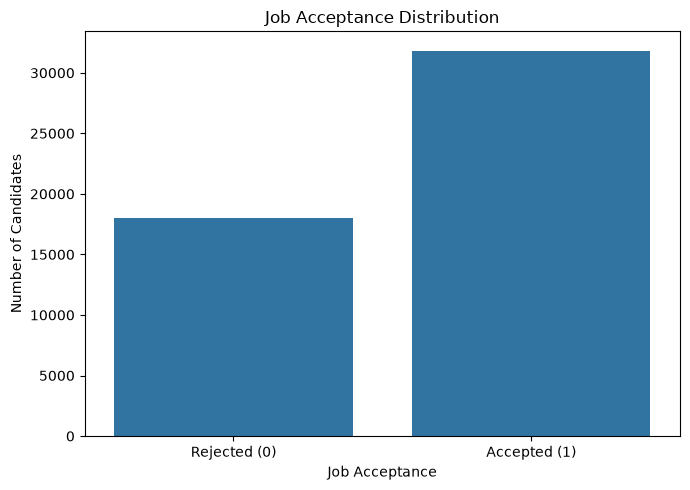

In [34]:
# 34. Plot target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Job_Accepted",
    data=df
)

plt.xticks(
    [0, 1],
    ["Rejected (0)", "Accepted (1)"]
)

plt.xlabel("Job Acceptance")
plt.ylabel("Number of Candidates")
plt.title("Job Acceptance Distribution")

plt.tight_layout()
plt.show()


## 9. Final Data Quality Checks


In [35]:
# 35. Final missing-value check

remaining_missing = (
    df.isna().sum()
    .sort_values(ascending=False)
)

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if remaining_missing.empty:
    print("✓ No missing values remain.")
else:
    print("Remaining missing values:")
    display(remaining_missing)


✓ No missing values remain.


In [36]:
# 36. Final duplicate checks

final_exact_duplicates = int(df.duplicated().sum())
final_duplicate_like = int(
    df.duplicated(subset=duplicate_features).sum()
)

print("Exact duplicate rows:", final_exact_duplicates)
print("Duplicate-like rows:", final_duplicate_like)


Exact duplicate rows: 0
Duplicate-like rows: 0


In [37]:
# 37. Final numeric range validation

final_invalid_records = []

for column, (minimum, maximum) in numeric_range_rules.items():
    if column not in df.columns:
        continue

    invalid_mask = (
        (df[column] < minimum)
        | (df[column] > maximum)
    )

    final_invalid_records.append({
        "Column": column,
        "Invalid_Count": int(invalid_mask.sum()),
        "Allowed_Range": f"{minimum} - {maximum}"
    })

final_invalid_summary = pd.DataFrame(final_invalid_records)

invalid_after_cleaning = final_invalid_summary[
    final_invalid_summary["Invalid_Count"] > 0
]

if invalid_after_cleaning.empty:
    print("✓ No invalid numeric values remain.")
else:
    display(invalid_after_cleaning)


✓ No invalid numeric values remain.


In [38]:
# 38. Candidate ID validation

candidate_id_missing = int(
    df["Candidate_ID"].isna().sum()
)

candidate_id_duplicates = int(
    df["Candidate_ID"].duplicated().sum()
)

print("Missing Candidate_ID:", candidate_id_missing)
print("Duplicate Candidate_ID:", candidate_id_duplicates)


Missing Candidate_ID: 0
Duplicate Candidate_ID: 0


In [39]:
# 39. Final summary

print("=" * 60)
print("FINAL CLEANED DATASET SUMMARY")
print("=" * 60)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Exact duplicates: {df.duplicated().sum():,}")
print(f"Target values: {sorted(df['Job_Accepted'].unique())}")

display(df.head(10))


FINAL CLEANED DATASET SUMMARY
Rows: 49,860
Columns: 36
Missing values: 0
Exact duplicates: 0
Target values: [np.int64(0), np.int64(1)]


,Candidate_ID,Age,Gender,Education_Level,Degree_Field,University_Tier,CGPA,Years_of_Experience,Previous_Companies,Internship_Experience,Certifications_Count,Technical_Skills_Score,Soft_Skills_Score,Skills_Match_Percentage,Aptitude_Score,Communication_Score,Interview_Score,Interview_Rounds,Job_Role,Industry,Company_Tier,Company_Size,Job_Type,Work_Mode,Job_Location,Preferred_Location,Relocation_Willingness,Competition_Level,Expected_Salary,Offered_Salary,Career_Growth_Score,Benefits_Score,Job_Security_Score,Notice_Period_Days,Offer_to_Joining_Days,Job_Accepted
0,CAND00001,28.00,Male,Diploma,Computer Science,Tier 2,7.60,5.20,3.00,No,0.00,74.40,78.50,54.50,88.50,80.90,80.30,3,Data Scientist,Telecom,Tier 3,Small,Contract,Hybrid,Mumbai,Pune,Yes,Medium,"1,225,000.00","1,198,000.00",92.10,62.00,77.50,30,54,0
1,CAND00002,22.00,Female,Bachelor's,Engineering,Tier 3,7.74,1.50,0.00,No,5.00,58.60,95.70,37.50,81.50,81.60,92.30,5,Data Scientist,Healthcare,Tier 2,Large,Part-Time,Hybrid,Mumbai,Bangalore,No,Medium,"1,029,000.00","1,168,000.00",93.80,94.60,55.40,30,44,1
2,CAND00003,30.00,Female,Master's,Business Administration,Tier 1,8.28,5.10,3.00,Yes,1.00,99.40,72.00,72.80,82.80,57.80,82.90,4,Operations Analyst,Consulting,Tier 1,Medium,Full-Time,Hybrid,Delhi,Delhi,Yes,Medium,"644,000.00","681,000.00",84.40,65.90,66.30,30,31,0
3,CAND00004,31.00,Female,Bachelor's,Data Science,Tier 2,7.96,5.50,3.00,No,3.00,76.40,87.20,57.30,75.10,72.40,83.50,3,Software Engineer,Consulting,Tier 1,Small,Full-Time,Hybrid,Bangalore,Hyderabad,No,Low,"1,166,000.00","1,213,000.00",87.30,85.60,79.70,45,58,1
4,CAND00005,20.00,Male,Bachelor's,Computer Science,Tier 3,7.96,0.00,0.00,No,2.00,63.90,80.40,44.00,77.90,75.60,69.30,3,Marketing Analyst,IT,Tier 1,Large,Full-Time,Remote,Hyderabad,Hyderabad,Yes,Medium,"597,000.00","666,000.00",83.70,76.40,79.30,15,37,1
5,CAND00006,21.00,Male,Diploma,Finance,Tier 2,8.32,0.00,0.00,Yes,1.00,80.40,66.40,47.20,67.10,67.50,60.20,4,Software Engineer,Telecom,Tier 2,Medium,Contract,Onsite,Delhi,Mumbai,No,Medium,"763,000.00","870,000.00",62.10,75.80,77.50,30,53,1
6,CAND00007,28.00,Female,Bachelor's,Other,Tier 2,8.22,4.10,2.00,No,5.00,77.60,62.90,70.60,77.90,64.20,67.60,2,Data Analyst,E-commerce,Tier 1,Large,Full-Time,Onsite,Kolkata,Delhi,Yes,High,"604,000.00","729,000.00",85.60,71.40,76.00,30,41,0
7,CAND00008,26.00,Other,Master's,Arts,Tier 1,7.60,2.00,1.00,Yes,3.00,90.90,87.70,60.10,81.70,86.10,87.90,4,Operations Analyst,Healthcare,Tier 2,Large,Full-Time,Hybrid,Pune,Delhi,No,Medium,"651,000.00","693,000.00",48.50,55.40,52.10,60,62,0
8,CAND00009,27.00,Female,Master's,Finance,Tier 2,7.05,4.00,2.00,Yes,3.00,58.40,81.40,43.20,62.20,81.10,78.10,4,Operations Analyst,Finance,Tier 2,Medium,Contract,Hybrid,Chennai,Delhi,No,Medium,"822,000.00","770,000.00",71.40,46.30,58.30,90,92,1
9,CAND00010,23.00,Male,Bachelor's,Engineering,Tier 3,6.82,0.90,1.00,No,1.00,80.50,90.60,62.60,59.70,85.60,80.80,5,Financial Analyst,IT,Tier 2,Medium,Part-Time,Onsite,Bangalore,Delhi,No,Low,"574,000.00","553,000.00",74.60,62.90,52.90,30,43,1


## 10. Save Cleaned Dataset


In [40]:
# 40. Save cleaned dataset

os.makedirs(PROCESSED_DIR, exist_ok=True)

df.to_csv(
    CLEAN_PATH,
    index=False
)

print("✓ Cleaned dataset saved.")
print(CLEAN_PATH)
print(
    f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns"
)


✓ Cleaned dataset saved.
d:\job acceptance prediction system\data\processed\cleaned_job_acceptance_data.csv
Shape: 49,860 rows × 36 columns


In [41]:
# 41. Reload and verify saved dataset

verification_df = pd.read_csv(CLEAN_PATH)

print("Reload verification successful.")
print("Shape:", verification_df.shape)
print(
    "Missing values:",
    int(verification_df.isna().sum().sum())
)
print(
    "Duplicate rows:",
    int(verification_df.duplicated().sum())
)
print(
    "Target values:",
    sorted(verification_df["Job_Accepted"].unique())
)


Reload verification successful.
Shape: (49860, 36)
Missing values: 0
Duplicate rows: 0
Target values: [np.int64(0), np.int64(1)]


In [42]:
# 42. Final verification report

verification_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Exact Duplicates",
        "Accepted Candidates",
        "Rejected Candidates"
    ],
    "Value": [
        len(verification_df),
        verification_df.shape[1],
        int(verification_df.isna().sum().sum()),
        int(verification_df.duplicated().sum()),
        int((verification_df["Job_Accepted"] == 1).sum()),
        int((verification_df["Job_Accepted"] == 0).sum())
    ]
})

display(verification_report)


,Metric,Value
0,Rows,49860
1,Columns,36
2,Missing Values,0
3,Exact Duplicates,0
4,Accepted Candidates,31835
5,Rejected Candidates,18025


In [43]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
d:\job acceptance prediction system\.venv\Scripts\python.exe

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
